<function matplotlib.pyplot.show(close=None, block=None)>

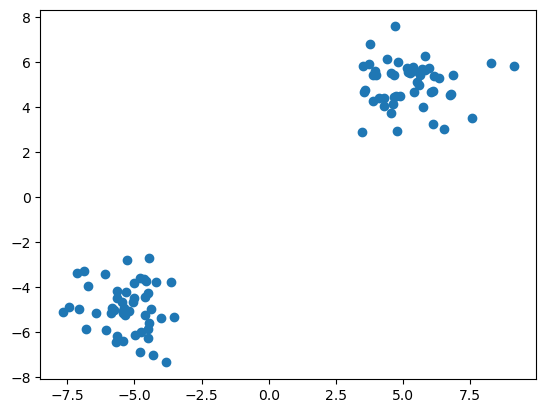

In [ ]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

centroids = [(-5,-5),(5,5)]
cluster_std = [1,1]

X,y = make_blobs(n_samples=100,cluster_std=cluster_std,centers=centroids,n_features=2,random_state=2)

plt.scatter(X[:,0],X[:,1])
plt.show

In [3]:
import random
import numpy as np

class KMeans:
    def __init__(self,n_clusters=2,max_iter=100):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.centroids = None


    def fir_predict(self,X):
        random_index = random.sample(0,X.shape[0],self.n_clusters)
        self.centroids = X[random_index]

        for i in range(self.max_iter):
            # assign clusters
            cluster_group =self.assign_clusters(X)
            old_centroids = self.centroids

            # move centroids
            self.move_centroids = self.move_centroids(X,cluster_group)

            # check finish
            if (old_centroids == self.centroids).all():
                break
        

    def assign_clusters(self,X):
        cluster_group = []
        distances = []
        for row in X:
            for centroid in self.centroids:
                distances.append(np.sqrt(np.dot(row-centroid,row-centroid)))
            min_distances = min(distances)
            indiex_pos = distances.indes(min_distances)
            cluster_group.append(indiex_pos)
            distances.clear()
        return np.array(cluster_group)
    
    
    def move_centroids(self,X,cluster_group):
        new_centroids = []
        cluster_type=np.unique(cluster_group)
        for type in cluster_type:
            new_centroids.append(X[cluster_group == type].mean(axis=0))
        return np.array(new_centroids) 


    